In [118]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [119]:
df = pd.read_csv('Dataset_1.csv')
# df.head()
# df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202000 entries, 0 to 201999
Data columns (total 48 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   accident_id                202000 non-null  object 
 1   accident_datetime          202000 non-null  object 
 2   state                      202000 non-null  object 
 3   district                   195938 non-null  object 
 4   area_type                  202000 non-null  object 
 5   latitude                   192022 non-null  float64
 6   longitude                  192022 non-null  float64
 7   road_type                  202000 non-null  object 
 8   road_condition             202000 non-null  object 
 9   road_lighting              195936 non-null  object 
 10  number_of_lanes            193914 non-null  float64
 11  speed_limit_kmph           191888 non-null  float64
 12  estimated_speed_kmph       202000 non-null  float64
 13  junction_type              19

In [120]:
df.describe()

,latitude,longitude,number_of_lanes,speed_limit_kmph,estimated_speed_kmph,visibility_km,temperature_c,rainfall_mm,driver_age,driving_experience_years,vehicle_age_years,response_time_minutes,num_vehicles,num_injuries,num_fatalities,insurance_claim_amount
count,192022.000000,192022.000000,193914.00000,191888.000000,202000.000000,189879.000000,191903.000000,202000.000000,173756.000000,173756.000000,173756.000000,96227.000000,202000.000000,202000.000000,202000.000000,91096.000000
mean,21.762030,77.979976,2.84785,58.830516,61.670709,4.912759,22.199841,3.488586,36.482193,16.723268,5.482622,21.916837,2.536163,1.083762,0.120337,41097.798465
std,8.743458,15.193053,1.42158,23.129471,29.602714,2.851291,8.149343,10.438514,12.820925,11.906786,5.392957,19.077603,1.456641,1.401991,0.531508,38272.018771
min,-89.993206,-179.316379,1.00000,20.000000,5.000000,0.020000,2.000000,0.000000,13.000000,0.000000,0.000000,2.000000,1.000000,0.000000,-1.000000,3000.000000
25%,17.832292,75.580903,2.00000,40.000000,39.900000,2.660000,15.600000,0.000000,27.000000,7.100000,1.600000,7.348077,2.000000,0.000000,0.000000,13899.750000
50%,23.361621,77.912843,2.00000,60.000000,57.300000,4.710000,22.300000,0.000000,36.000000,16.000000,3.800000,17.658348,2.000000,1.000000,0.000000,29458.500000
75%,26.645448,82.083551,4.00000,70.000000,78.200000,7.360000,28.800000,0.000000,45.000000,24.900000,7.600000,30.049904,3.000000,2.000000,0.000000,55813.500000
max,89.967149,179.807326,6.00000,120.000000,160.000000,10.850000,47.000000,252.100000,102.000000,55.000000,30.000000,180.000000,24.000000,13.000000,15.000000,434334.000000


- Min max values of each column is Justify
- estimated_speed_kmph, rainfall_mm, insurance_claim_amount is hogh ly ditributed by comapring mean and sd value 
- For num_fatalities min value is -1 which is not possible

## Univariant Analysis

In [121]:
# Outliers detection
int_cols = df.select_dtypes(include=['float64','int64']).columns
for col in int_cols:
    print(col,"==>",df[col].unique())
int_cols

latitude ==> [15.7410672  30.2111265  23.78297177 ... 29.57750844 27.54434377
 18.19726781]
longitude ==> [74.55504745 75.46189675 86.28110307 ... 82.37117505 82.83045526
 76.64696546]
number_of_lanes ==> [ 6.  2.  3.  1.  4. nan]
speed_limit_kmph ==> [ nan 120.  60.  40.  80.  30.  70. 100.  50.  20.]
estimated_speed_kmph ==> [80.8 96.2 76.4 ...  8.1  6.7  5.8]
visibility_km ==> [ 3.76  4.71  3.16 ... 10.59 10.8  10.68]
temperature_c ==> [ 9.   nan 28.8 12.8 18.4 21.5 30.3 23.6 32.9 22.2 33.9 29.5 29.6 22.8
 31.9 34.5 17.7 10.1 24.8 26.3 15.  26.4 19.4 18.9 19.  24.6 12.  30.7
 33.1 34.2 20.  18.3 15.8 19.5 14.3  8.5 28.4 13.4 18.6 16.8  7.9 30.9
 19.9 24.7 36.6 23.8 19.6 28.5  9.3 12.3 33.6 25.4 28.9 15.5 28.6 20.8
 21.1 25.2 12.2 10.6 12.1 27.6 16.7 37.8 22.1 37.4  3.9  6.3 19.7 21.6
  7.2 17.5 26.7 18.2 27.9 21.  31.3 24.5 23.2 32.2 25.5  8.4 22.6 26.5
 30.4 12.7 20.5 26.9 16.3 25.7 35.3 14.  29.3 29.9 32.  23.3 19.8 27.5
 28.3 15.4 41.8 20.6 18.1 28.2 23.7 13.3 35.8 17.6 10.4 23. 

Index(['latitude', 'longitude', 'number_of_lanes', 'speed_limit_kmph',
       'estimated_speed_kmph', 'visibility_km', 'temperature_c', 'rainfall_mm',
       'driver_age', 'driving_experience_years', 'vehicle_age_years',
       'response_time_minutes', 'num_vehicles', 'num_injuries',
       'num_fatalities', 'insurance_claim_amount'],
      dtype='object')

In [122]:
df[int_cols].isnull().sum()

latitude                      9978
longitude                     9978
number_of_lanes               8086
speed_limit_kmph             10112
estimated_speed_kmph             0
visibility_km                12121
temperature_c                10097
rainfall_mm                      0
driver_age                   28244
driving_experience_years     28244
vehicle_age_years            28244
response_time_minutes       105773
num_vehicles                     0
num_injuries                     0
num_fatalities                   0
insurance_claim_amount      110904
dtype: int64

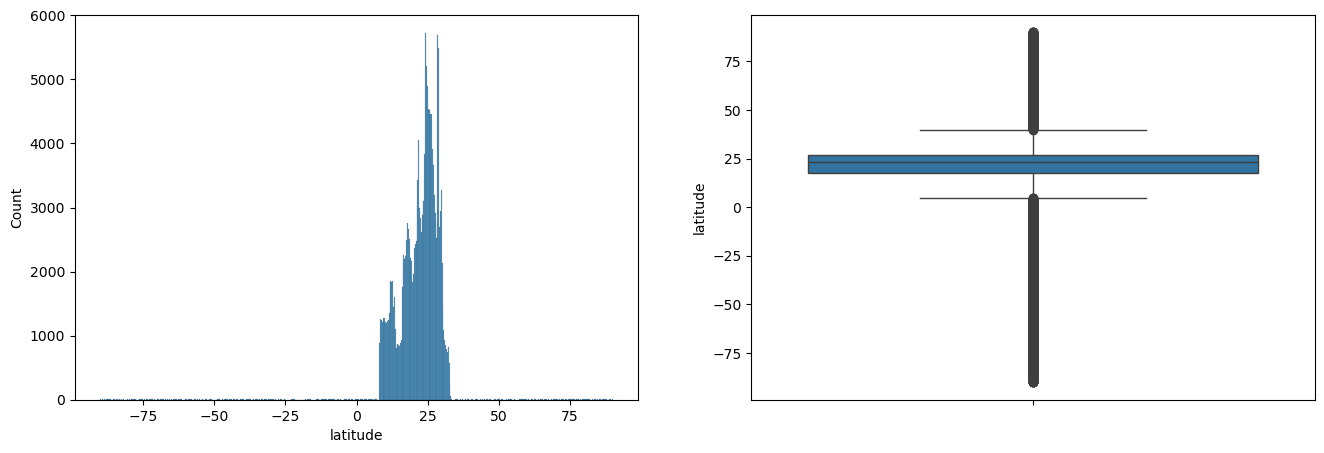

In [123]:
# latitude
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.histplot(df['latitude'])
# plt.xlim(0, 50)

plt.subplot(1,2,2)
sns.boxplot(df['latitude'])

plt.show() 

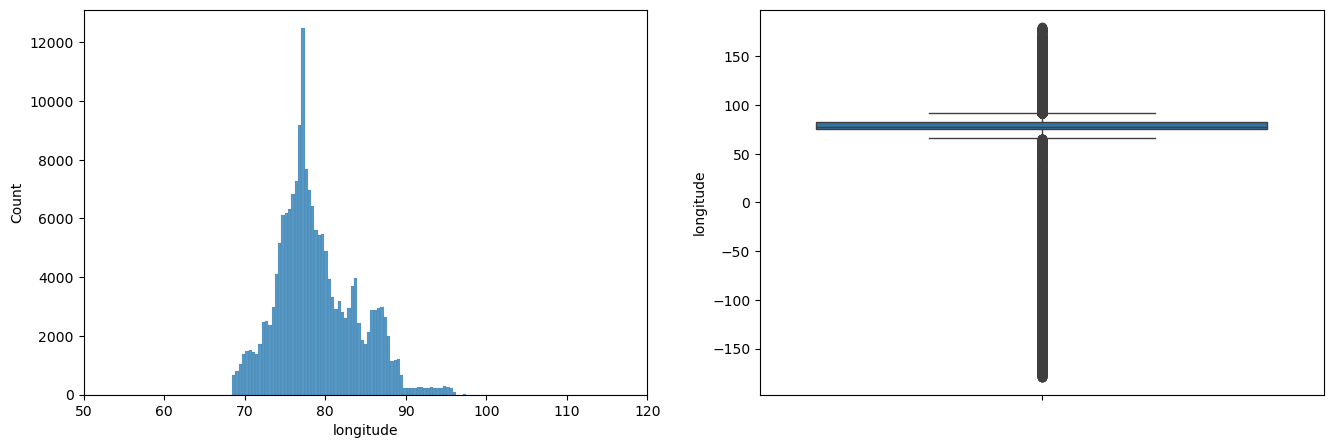

In [124]:
# longitude
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['longitude'])
plt.xlim(50, 120)

plt.subplot(1,2,2)
sns.boxplot(df["longitude"])
# plt.ylim(0,120)
plt.show()

- As we see there is mostly value beteween 70-90
- but there is many mid outlier but as my opinion this is ralistic data data 

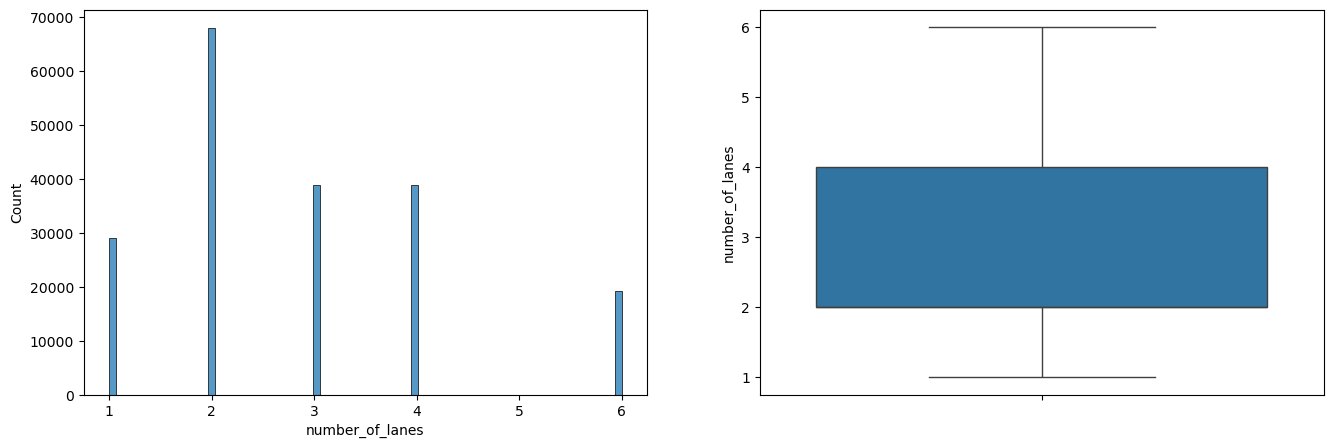

In [125]:
# number_of_lanes
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['number_of_lanes'])

plt.subplot(1,2,2)
sns.boxplot(df['number_of_lanes'])

plt.show()


Maximum roads are 2 lane road

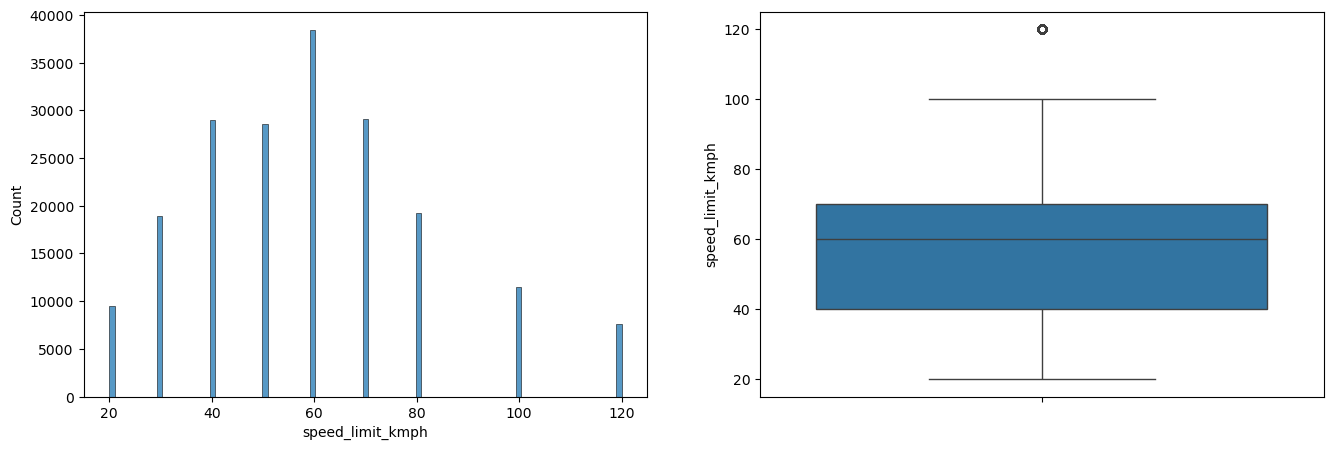

In [126]:
# speed_limit_kmph
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['speed_limit_kmph'])

plt.subplot(1,2,2)
sns.boxplot(df['speed_limit_kmph'])

plt.show()
# Conclusion speed_limit_kmph has outliers, we can remove the outliers

Speed Limit in many road are beteween 40-80

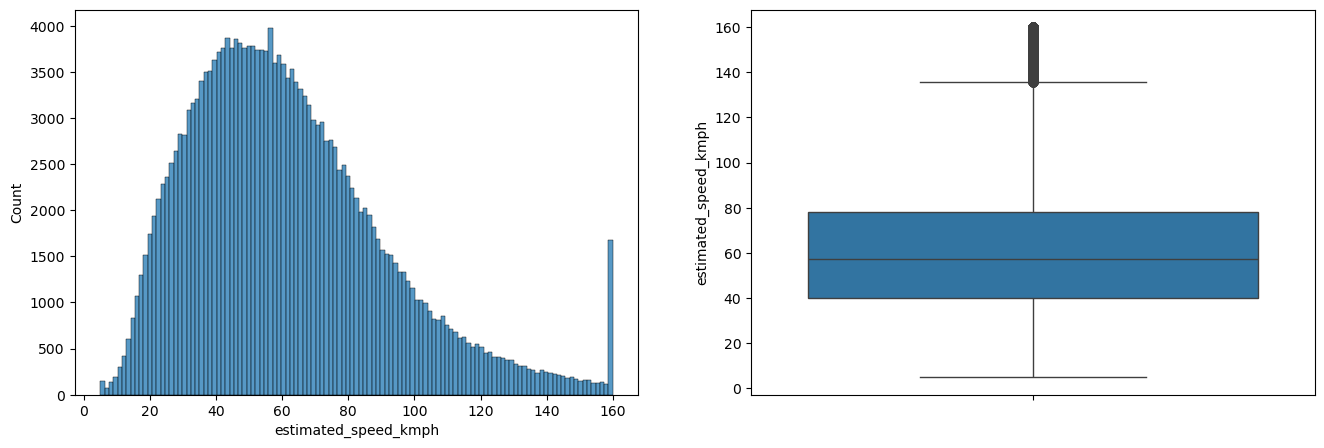

In [127]:
# estimated_speed_kmph
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['estimated_speed_kmph'])

plt.subplot(1,2,2)
sns.boxplot(df['estimated_speed_kmph'])

plt.show()

Estimated_speed_Kmph is mostly in beteween 20-80 but there is some outier need to be fix

In [128]:
Q1 = df['estimated_speed_kmph'].quantile(0.25)
Q3 = df['estimated_speed_kmph'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Remove outliers
df = df[(df['estimated_speed_kmph'] >= lower_bound) & (df['estimated_speed_kmph'] <= upper_bound)]

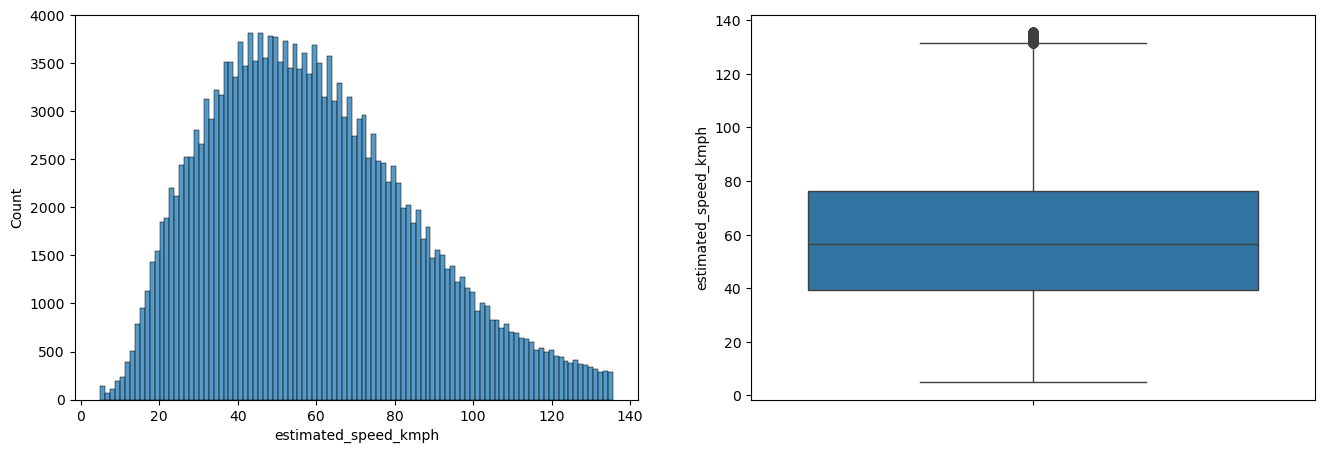

In [129]:
# estimated_speed_kmph after removing outliers
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['estimated_speed_kmph'])

plt.subplot(1,2,2)
sns.boxplot(df['estimated_speed_kmph'])

plt.show()

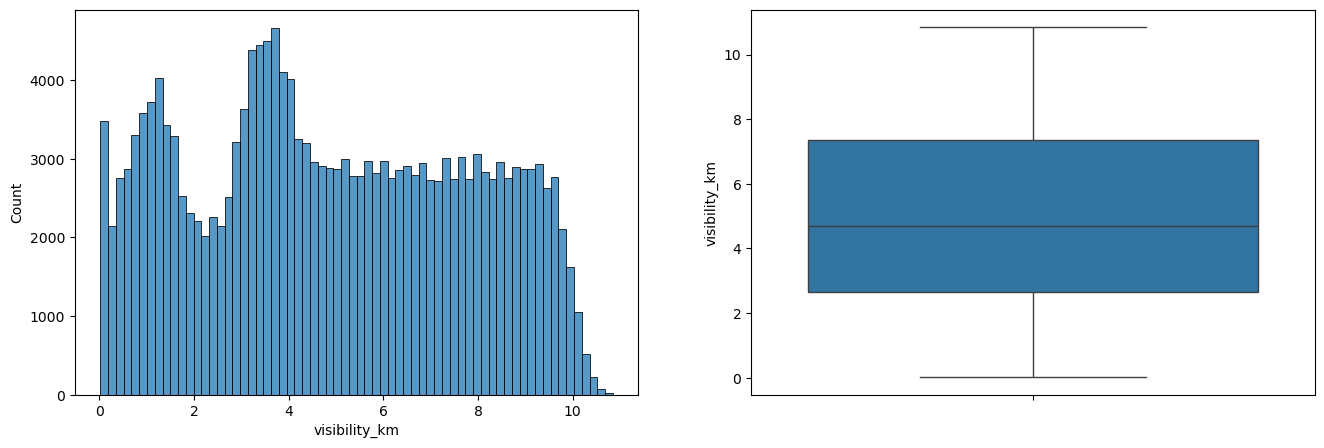

In [130]:
# response_time_minutes and vehicle_age_years outlier
# visibility_km
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['visibility_km'])

plt.subplot(1,2,2)
sns.boxplot(df['visibility_km'])

plt.show()
# conclusion visibility_km has no outliers

Visibilty data is weell justify no need any operation

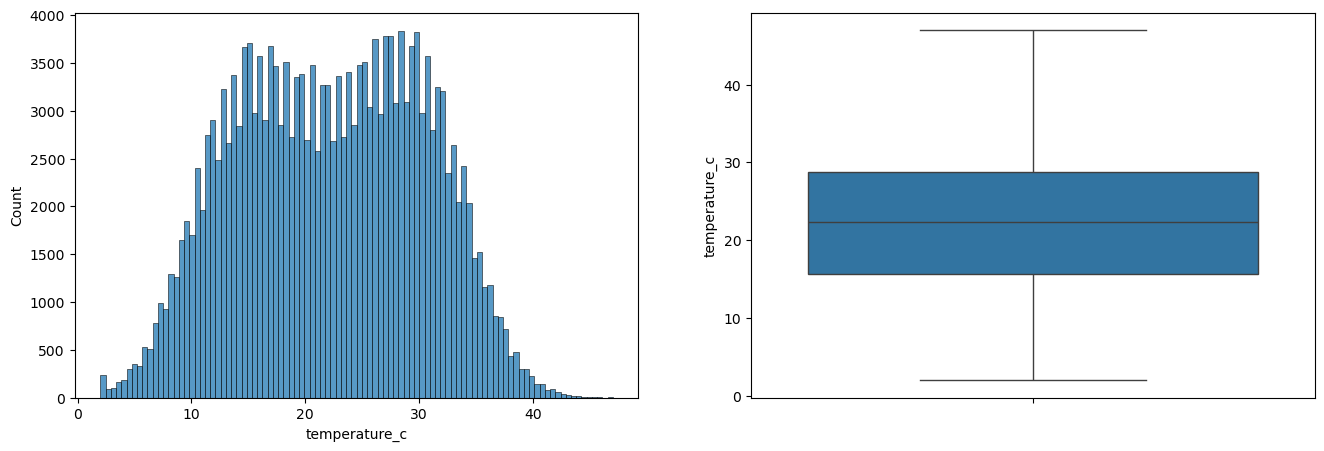

In [131]:
# temperature_c
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['temperature_c'])

plt.subplot(1,2,2)
sns.boxplot(df['temperature_c'])

plt.show()
# Conclusion temperature_c has no outliers

Temperature is mostly beteween in 10-35 

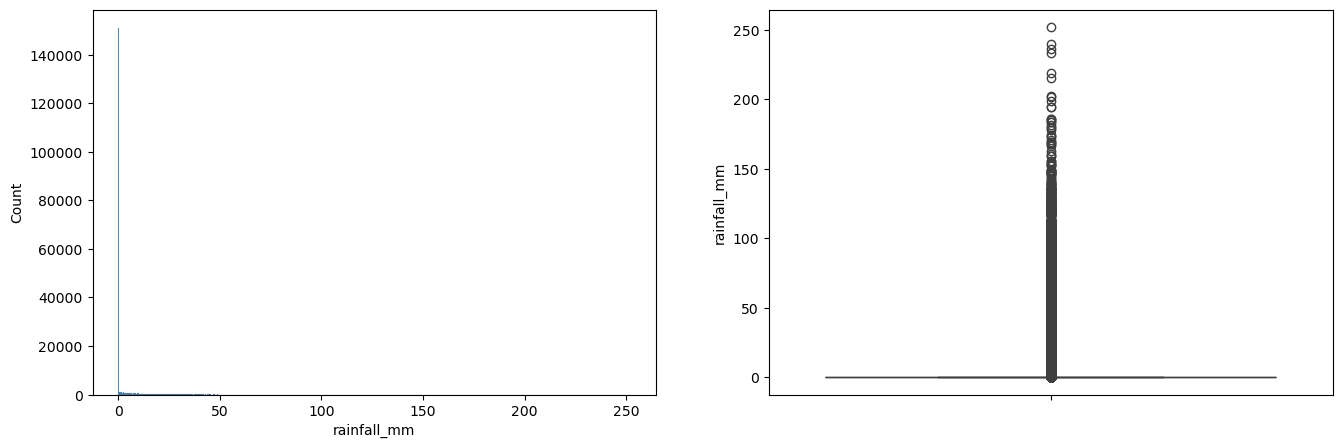

In [132]:
# rainfall_mm
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['rainfall_mm'])

plt.subplot(1,2,2)
sns.boxplot(df['rainfall_mm'])

plt.show()

Maximum area is dry but there is some area which conatain heavy rainfall


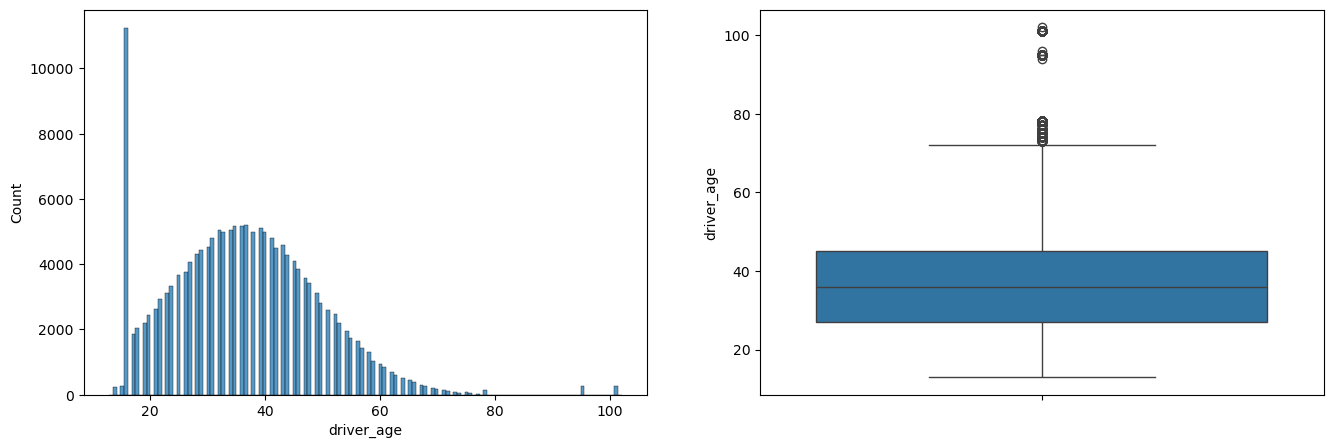

In [133]:
# driver_age
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['driver_age'])

plt.subplot(1,2,2)
sns.boxplot(df['driver_age'])

plt.show()

- Avereage age of driver is 25-60 but outside that it might be an outlier
- operation needed to remove the outlier

In [134]:
# Remove outliers
df = df[(df['driver_age'] >= 18) & (df['driver_age'] <= 70)]

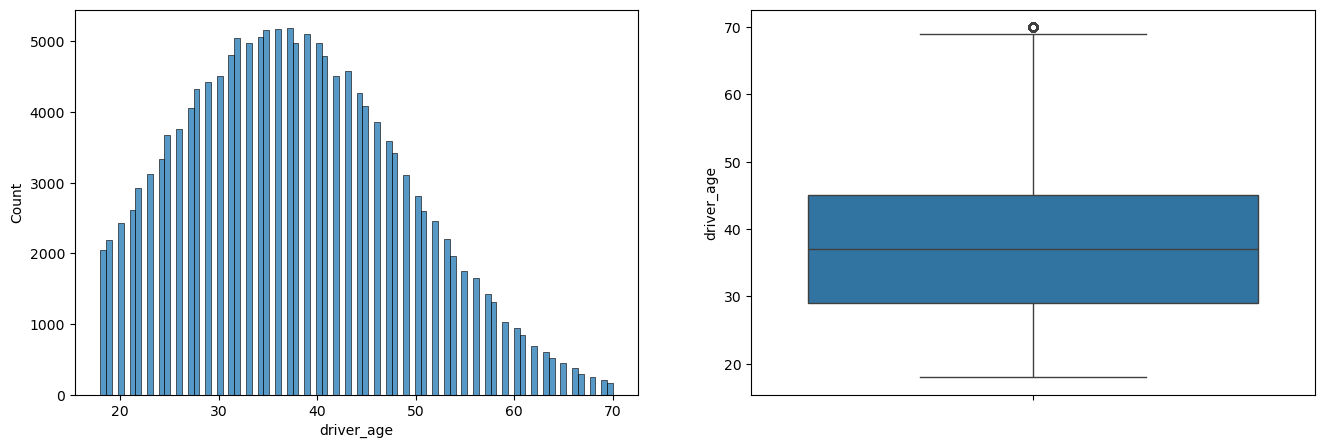

In [135]:
# driver_age after removing outliers
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['driver_age'])

plt.subplot(1,2,2)
sns.boxplot(df['driver_age'])

plt.show()

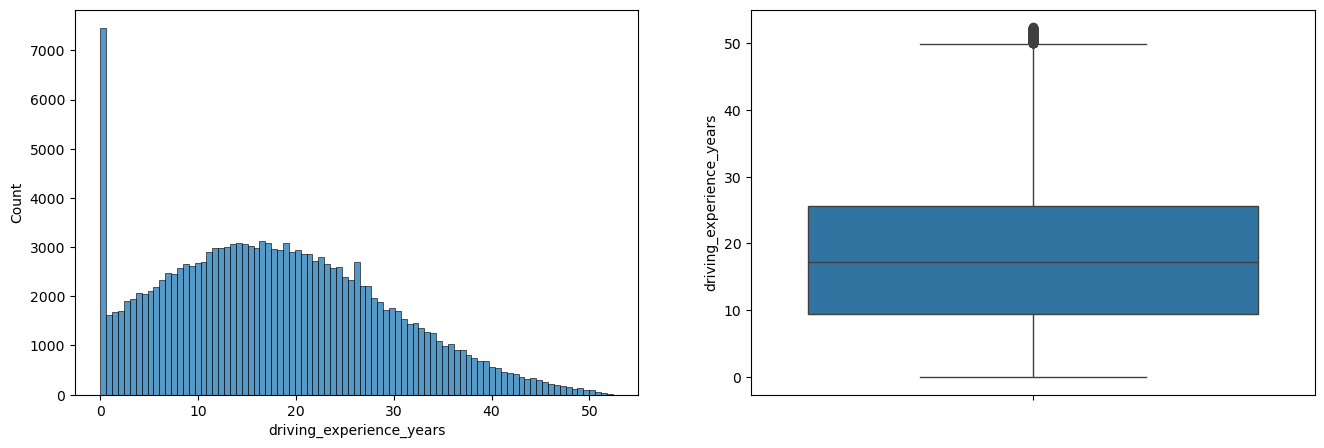

In [136]:
# driving_experience_years
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['driving_experience_years'])

plt.subplot(1,2,2)
sns.boxplot(df['driving_experience_years'])

plt.show()
# Conclusion driving_experience_years has outliers, we can remove the outliers

- Driver experience year is zero for maximum driver, but also there is also some experienced driver

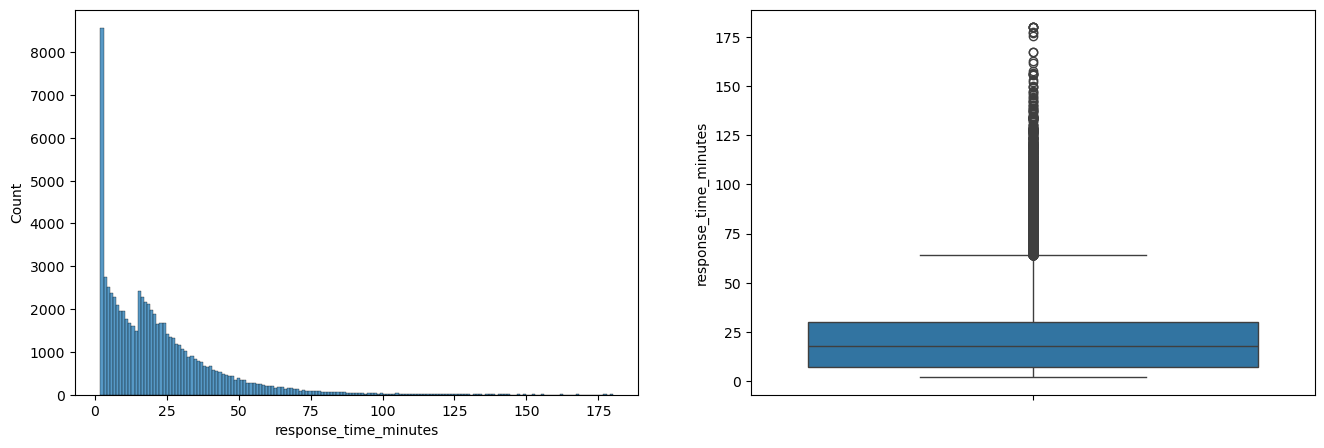

In [137]:
# response_time_minutes
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['response_time_minutes'])

plt.subplot(1,2,2)
sns.boxplot(df['response_time_minutes'])

plt.show()

by data it is clearly visible that response wil given wuthin 30 min

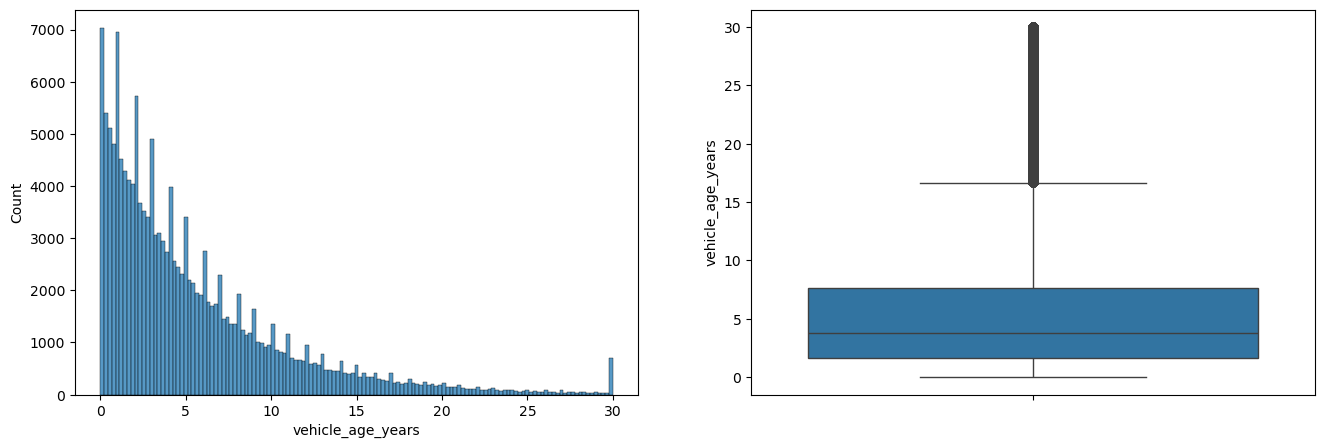

In [138]:
# vehicle_age_years
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['vehicle_age_years'])

plt.subplot(1,2,2)
sns.boxplot(df['vehicle_age_years'])

plt.show()

maximum vehicle is new but there are some vehicle whose age is 30 

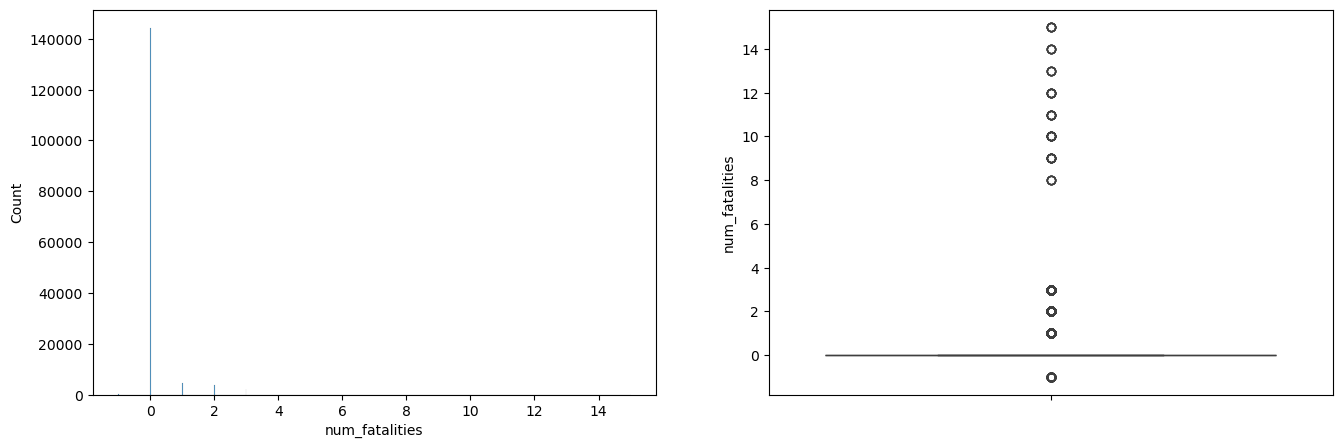

In [139]:
# num_fatalities
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['num_fatalities'])

plt.subplot(1,2,2)
sns.boxplot(df['num_fatalities'])

plt.show()

There is a value below zero which is not possible

In [140]:
df = df.drop(df[df['num_fatalities'] < 0].index)

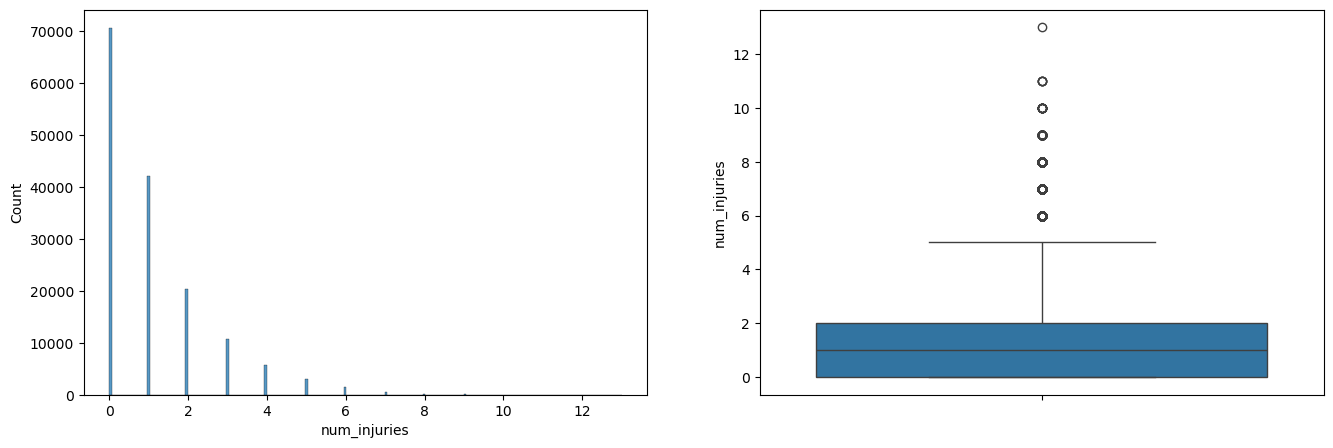

In [141]:
# num_injuries
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['num_injuries'])

plt.subplot(1,2,2)
sns.boxplot(df['num_injuries'])

plt.show()

in mostly accident there no person get injured but there is major accident where many person injured

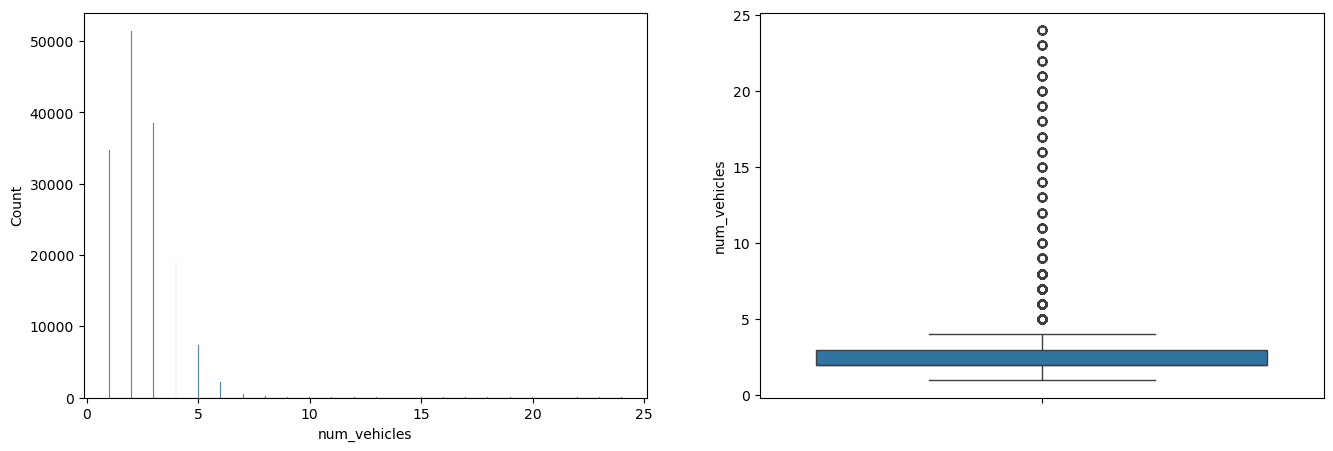

In [142]:
# num_vehicles
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['num_vehicles'])

plt.subplot(1,2,2)
sns.boxplot(df['num_vehicles'])

plt.show()

In [143]:
# Handling missing values for int_cols
from sklearn.impute import SimpleImputer
median_imputer = SimpleImputer(strategy='median')
df[int_cols] = median_imputer.fit_transform(df[int_cols])

In [150]:
df.isnull().sum()

accident_id                  0
accident_datetime            0
state                        0
district                     0
area_type                    0
latitude                     0
longitude                    0
road_type                    0
road_condition               0
road_lighting                0
number_of_lanes              0
speed_limit_kmph             0
estimated_speed_kmph         0
junction_type                0
traffic_signal_present       0
median_present               0
weather_condition            0
visibility_km                0
temperature_c                0
rainfall_mm                  0
driver_age                   0
driver_gender                0
driving_experience_years     0
license_status               0
alcohol_involved             0
distraction_involved         0
mobile_phone_used            0
fatigue_involved             0
helmet_seatbelt_used         0
vehicle_type                 0
vehicle_age_years            0
vehicle_brand                0
vehicle_

In [148]:
obj_col = df.select_dtypes(include=['object']).columns
for col in obj_col:
    print(col,"==>",df[col].unique())

accident_id ==> ['ACC20240000709' 'ACC20180059148' 'ACC20160076737' ... 'ACC20220041187'
 'ACC20240117449' 'ACC20190162698']
accident_datetime ==> ['2024-12-15 15:14:47' '2018-07-24 16:43:57' '2016-11-17 17:53:16' ...
 '2022-09-17 10:30:59' '2024-06-23 16:17:20' '2019-06-17 13:21:45']
state ==> ['Karnataka' 'West Bengal' 'Rajasthan' 'Gujarat' 'Uttar Pradesh'
 'Maharashtra' 'Kerala' 'Chhattisgarh' 'Haryana' 'Assam' 'Andhra Pradesh'
 'Bihar' 'Himachal Pradesh' 'Delhi' 'Madhya Pradesh' 'Jharkhand' 'Odisha'
 'Telangana' 'Punjab' 'Tamil Nadu' 'Uttarakhand']
district ==> ['Hubli District' 'Siliguri District' 'Howrah District' 'Jodhpur District'
 'Vadodara District' 'Agra District' 'Mangaluru District'
 'Nagpur District' 'Aurangabad District' nan 'Kolkata District'
 'Varanasi District' 'Durg District' 'Ambala District' 'Kanpur District'
 'Nashik District' 'Jorhat District' 'Rajkot District'
 'Visakhapatnam District' 'Muzaffarpur District' 'Guwahati District'
 'Mumbai District' 'Patna District

In [146]:
obj_col

Index(['accident_id', 'accident_datetime', 'state', 'district', 'area_type',
       'road_type', 'road_condition', 'road_lighting', 'junction_type',
       'traffic_signal_present', 'median_present', 'weather_condition',
       'driver_gender', 'license_status', 'alcohol_involved',
       'distraction_involved', 'mobile_phone_used', 'fatigue_involved',
       'helmet_seatbelt_used', 'vehicle_type', 'vehicle_brand',
       'vehicle_model', 'vehicle_condition', 'overloading_status',
       'primary_cause', 'secondary_cause', 'emergency_services_called',
       'ambulance_called', 'police_called', 'hospitalization_required',
       'accident_severity', 'insurance_claim_filed'],
      dtype='object')

From This we got to know there is inconsistesy in data

In [147]:
df['road_type'] = df['road_type'].map({  'state highway':'State Highway', ' State Highway ':'State Highway', 'STATE HIGHWAY' : 'State Highway', 'EXPRESSWAY':'Expressway', 'expressway':'Expressway', ' Expressway ':'Expressway', 'national highway':'National Highway', ' National Highway ':'National Highway', 'NATIONAL HIGHWAY':'National Highway', 'village road':'Village Road', 'VILLAGE ROAD':'Village Road', ' Village Road ':'Village Road', 'OTHER DISTRICT ROAD':'Other District Road', 'other district road':'Other District Road', ' Other District Road ':'Other District Road'})

df['traffic_signal_present'] = df['traffic_signal_present'].map({'0':'No','N':'No','True':'Yes','False':'No','Y':'Yes','1':'Yes'})
df['median_present'] = df['median_present'].map({'0':'No','N':'No','True':'Yes','False':'No','Y':'Yes','1':'Yes'})
df['mobile_phone_used'] = df['mobile_phone_used'].map({'0':'No','N':'No','True':'Yes','False':'No','Y':'Yes','1':'Yes'})

df['weather_condition'] = df['weather_condition'].map({'Rainy':'Rainy','rainy':'Rainy',' Rainy ':'Rainy','RAINY':'Rainy',' Clear ':'Clear', 'clear':'Clear', 'CLEAR':'Clear',' Foggy ':'Foggy','FOGGY':'Foggy', 'foggy':'Foggy','hazy':'Hazy','HAZY':'Hazy',' Hazy ':'Hazy','STORMY':'Stormy','stormy':'Stormy',' Stormy ':'Stormy'})



In [149]:
mode_imputer = SimpleImputer(strategy='most_frequent')
df[obj_col] = mode_imputer.fit_transform(df[obj_col])